In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/student_clustering.csv")

In [3]:
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


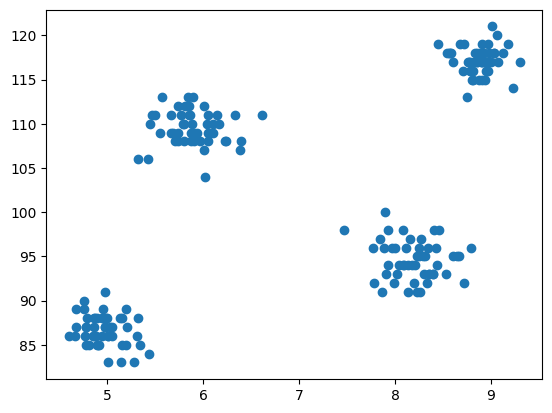

In [5]:
plt.scatter(x=df['cgpa'],y=df['iq'])

In [9]:
from sklearn.cluster import KMeans

In [14]:
wcss = []

for i in range(1,11):
  km = KMeans(n_clusters=i)
  km.fit_predict(df)
  wcss.append(km.inertia_)

In [15]:
wcss

[29957.898287999997,
 4184.141269999999,
 2503.3975810000015,
 681.9696600000001,
 514.1616803171117,
 405.1205840691053,
 351.9360122545987,
 300.85068127622606,
 264.7969526767228,
 188.97024470280112]

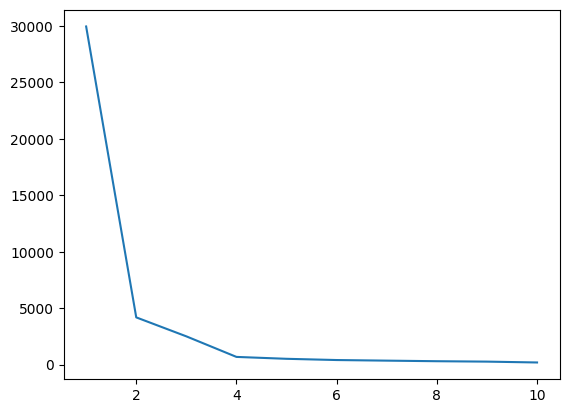

In [17]:
plt.plot(range(1,11),wcss)

In [19]:
X = df.iloc[:,:].values
km1 = KMeans(n_clusters=4)
y_means = km1.fit_predict(X)

In [24]:
X[y_means==1]

array([[  8.36,  93.  ],
       [  8.27,  97.  ],
       [  8.41,  98.  ],
       [  8.09,  94.  ],
       [  8.16,  97.  ],
       [  8.31,  95.  ],
       [  7.87,  91.  ],
       [  7.47,  98.  ],
       [  7.78,  92.  ],
       [  7.93,  98.  ],
       [  8.04,  94.  ],
       [  7.77,  96.  ],
       [  8.  ,  96.  ],
       [  8.43,  96.  ],
       [  8.02,  93.  ],
       [  8.14,  94.  ],
       [  8.12,  96.  ],
       [  8.34,  96.  ],
       [  8.65,  95.  ],
       [  8.53,  93.  ],
       [  8.29,  95.  ],
       [  7.93,  94.  ],
       [  8.72,  92.  ],
       [  8.14,  91.  ],
       [  8.2 ,  92.  ],
       [  8.67,  95.  ],
       [  8.18,  94.  ],
       [  8.61,  95.  ],
       [  7.99,  92.  ],
       [  8.08,  94.  ],
       [  8.26,  91.  ],
       [  8.25,  95.  ],
       [  8.4 ,  93.  ],
       [  7.84,  97.  ],
       [  8.08,  98.  ],
       [  8.25,  96.  ],
       [  8.3 ,  93.  ],
       [  7.9 , 100.  ],
       [  7.97,  96.  ],
       [  8.21,  94.  ],


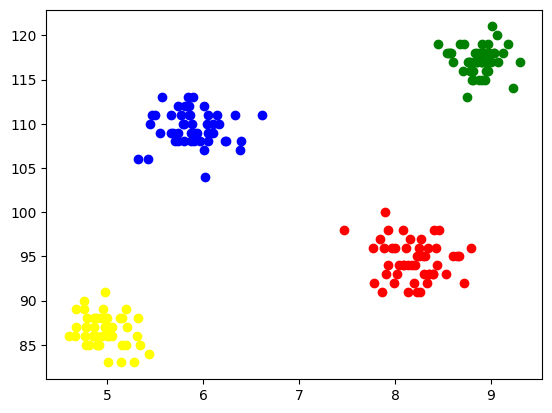

In [25]:
plt.scatter(X[y_means==0,0],X[y_means==0,1],color='blue')
plt.scatter(X[y_means==1,0],X[y_means==1,1],color='red')
plt.scatter(X[y_means==2,0],X[y_means==2,1],color='yellow')
plt.scatter(X[y_means==3,0],X[y_means==3,1],color='green')

In [27]:
## 3d
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)

In [28]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()

In [29]:
wcss = []
for i in range(1,21):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

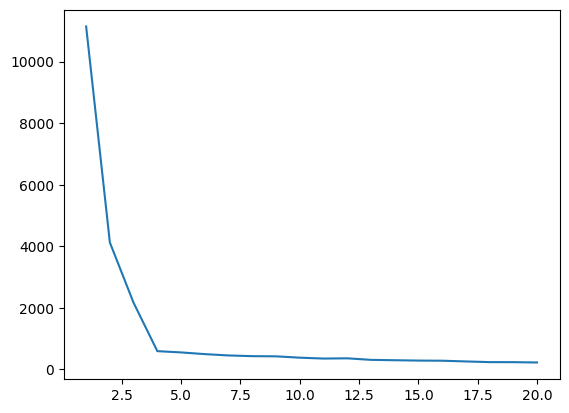

In [30]:
plt.plot(range(1,21),wcss)

In [31]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(X)

In [32]:
df = pd.DataFrame()

df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

In [33]:
fig = px.scatter_3d(df,x='col1', y='col2', z='col3',color='label')
fig.show()